# Generative Adversarial Networks (GAN) Demo

## Problem Statement
We want to generate realistic images of handwritten digits (0-9) similar to those in the popular MNIST dataset using a Generative Adversarial Network (GAN). The goal is to train a generator that can produce images indistinguishable from real handwritten digits.

---

## Dataset
We will use the **MNIST dataset**, which consists of:
- 60,000 training images
- 10,000 test images
- Each image is a grayscale 28x28 pixel representation of handwritten digits (0-9).

---

## GAN Architecture
A **GAN** consists of two neural networks:
1. **Generator**: Generates new images from random noise.
2. **Discriminator**: Distinguishes between real images (from the dataset) and fake images (generated by the generator).

The generator and discriminator are trained in opposition:
- **Generator** tries to produce images that the discriminator cannot distinguish from real ones.
- **Discriminator** tries to become better at distinguishing between real and fake images.

---

## Implementation

### Step 1: Import Libraries

In [1]:
# Importing necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

### Step 2: Data Preprocessing

In [2]:
# Data transformation and loading the MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


100%|██████████| 9.91M/9.91M [00:32<00:00, 301kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.15MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


### Step 3: Define the Generator

In [3]:
# Generator model
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 28*28),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(z.size(0), 1, 28, 28)
        return img

latent_dim = 100
generator = Generator(latent_dim)

### Step 4: Define the Discriminator

In [4]:
# Discriminator model
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        validity = self.model(img_flat)
        return validity

discriminator = Discriminator()


### Step 5: Loss Function and Optimizers

In [5]:
# Loss function and optimizers
criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002)
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002)


### Step 6: Training the GAN

In [ ]:
# Function to generate noise
def generate_noise(batch_size, latent_dim):
    return torch.randn(batch_size, latent_dim)

# Training loop
n_epochs = 50
for epoch in range(n_epochs):
    for imgs, _ in train_loader:
        # Ground truths for real (1) and fake (0)
        real_labels = torch.ones(imgs.size(0), 1)
        fake_labels = torch.zeros(imgs.size(0), 1)

        # ---------------------
        # Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()

        # Loss for real images
        real_imgs = imgs
        real_validity = discriminator(real_imgs)
        real_loss = criterion(real_validity, real_labels)

        # Loss for fake images
        z = generate_noise(imgs.size(0), latent_dim)
        fake_imgs = generator(z)
        fake_validity = discriminator(fake_imgs)
        fake_loss = criterion(fake_validity, fake_labels)

        # Total discriminator loss
        d_loss = real_loss + fake_loss
        d_loss.backward()
        optimizer_D.step()

        # ---------------------
        # Train Generator
        # ---------------------
        optimizer_G.zero_grad()

        # Generate fake images and calculate generator loss
        z = generate_noise(imgs.size(0), latent_dim)
        gen_imgs = generator(z)
        validity = discriminator(gen_imgs)
        g_loss = criterion(validity, real_labels)

        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{n_epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")


### Step 7: Generate and Visualize New Images

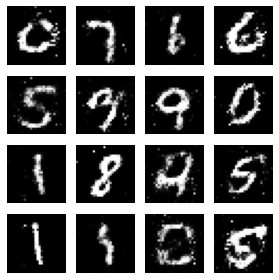

In [ ]:
# Generate new images after training
def generate_and_plot(generator, latent_dim, n_samples=16):
    z = generate_noise(n_samples, latent_dim)
    gen_imgs = generator(z).detach().cpu().numpy()
    gen_imgs = (gen_imgs + 1) / 2  # Rescale images to [0, 1]

    plt.figure(figsize=(4, 4))
    for i in range(n_samples):
        plt.subplot(4, 4, i+1)
        plt.imshow(gen_imgs[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

generate_and_plot(generator, latent_dim)
